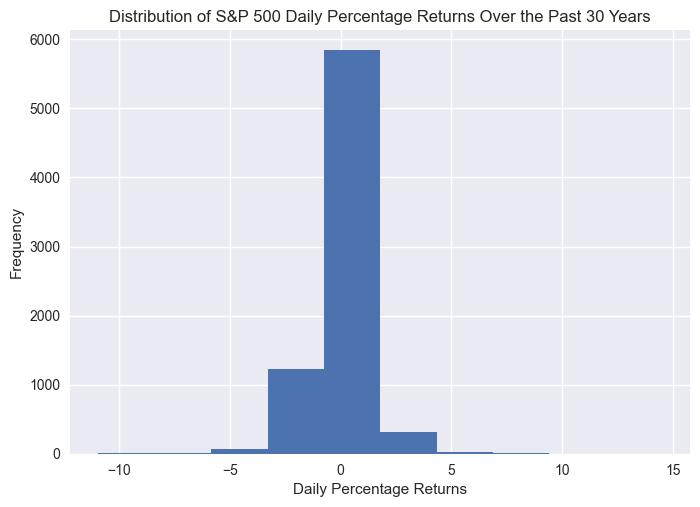

Descriptive statistics of S&P 500 percentage returns:
count    7481.00
mean        0.04
std         1.19
min       -10.94
25%        -0.44
50%         0.07
75%         0.59
max        14.52
Name: Returns, dtype: float64
The skewness of S&P 500 returns is: -0.07 and the kurtosis is: 11.43.


In [3]:
# Import Python libraries
import pandas as pd
from datetime import datetime
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import yfinance as yf
# Import over 30 years of S&P 500 ('SPY') price data into a dataframe called equity
start = datetime(1993, 2, 1)
end = datetime(2022, 10, 15)
equity = yf.Ticker('SPY').history(start=start, end=end)

# Use SPY's closing prices to compute its daily returns. 
# Remove NaNs from your dataframe.
equity['Returns'] = equity['Close'].pct_change(1)*100
equity = equity.dropna()

# Visualize and summarize SPY's daily price returns. 
# Compute its skewness and kurtosis.
plt.hist(equity['Returns']), plt.title('Distribution of S&P 500 Daily Percentage Returns Over the Past 30 Years'), plt.xlabel('Daily Percentage Returns'), 
plt.ylabel('Frequency'), plt.show()
print("Descriptive statistics of S&P 500 percentage returns:\n{}".format(equity['Returns'].describe().round(2)))
print('The skewness of S&P 500 returns is: {0:.2f} and the kurtosis is: {1:.2f}.' .format(equity['Returns'].skew(), equity['Returns'].kurtosis()))

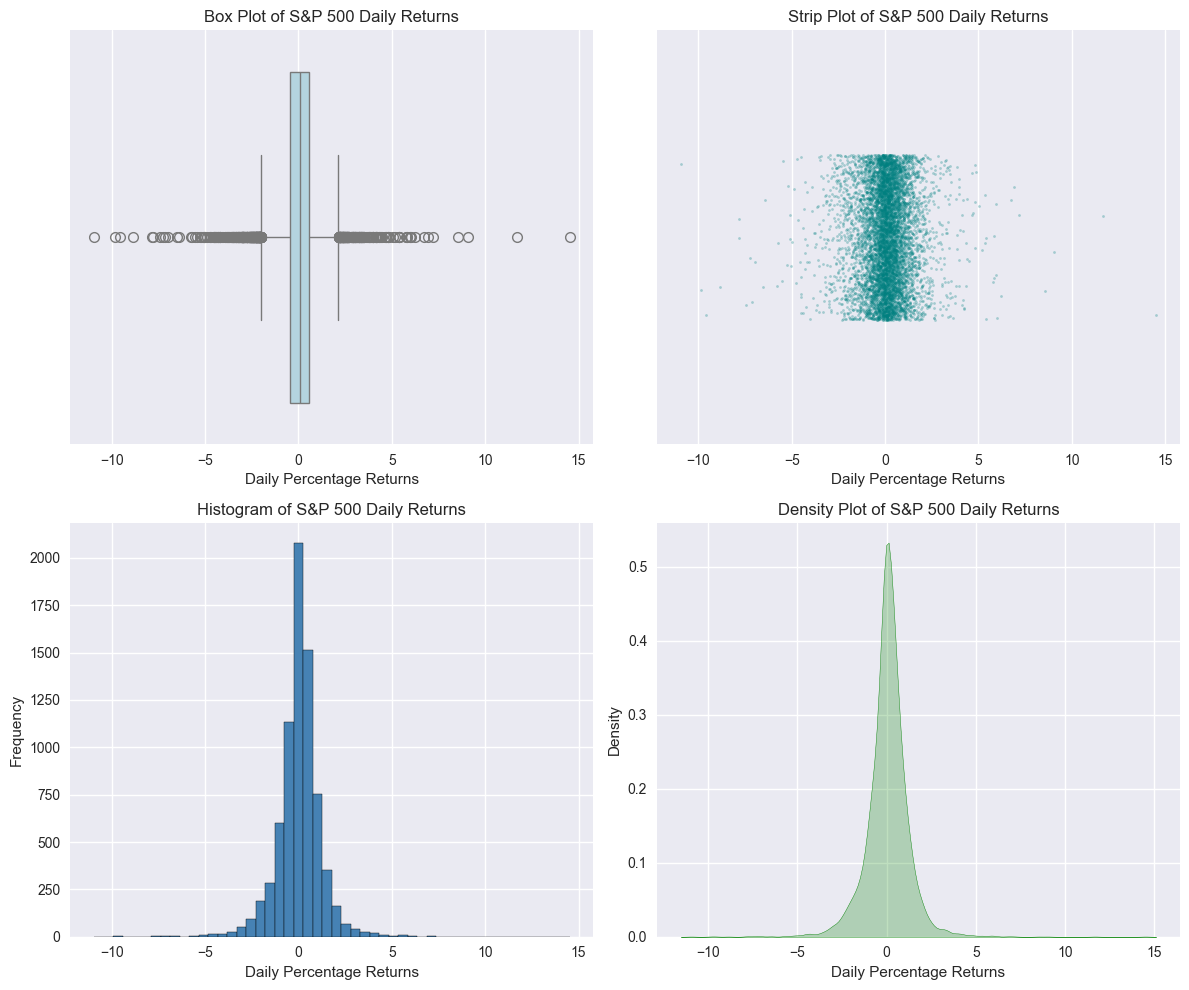

In [4]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(x=equity['Returns'], ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Box Plot of S&P 500 Daily Returns')
axes[0, 0].set_xlabel('Daily Percentage Returns')

sns.stripplot(x=equity['Returns'], ax=axes[0, 1], color='teal', alpha=0.3, jitter=0.2, size=2)
axes[0, 1].set_title('Strip Plot of S&P 500 Daily Returns')
axes[0, 1].set_xlabel('Daily Percentage Returns')

axes[1, 0].hist(equity['Returns'], bins=50, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Histogram of S&P 500 Daily Returns')
axes[1, 0].set_xlabel('Daily Percentage Returns')
axes[1, 0].set_ylabel('Frequency')

sns.kdeplot(equity['Returns'], fill=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Density Plot of S&P 500 Daily Returns')
axes[1, 1].set_xlabel('Daily Percentage Returns')

plt.tight_layout()
plt.show()

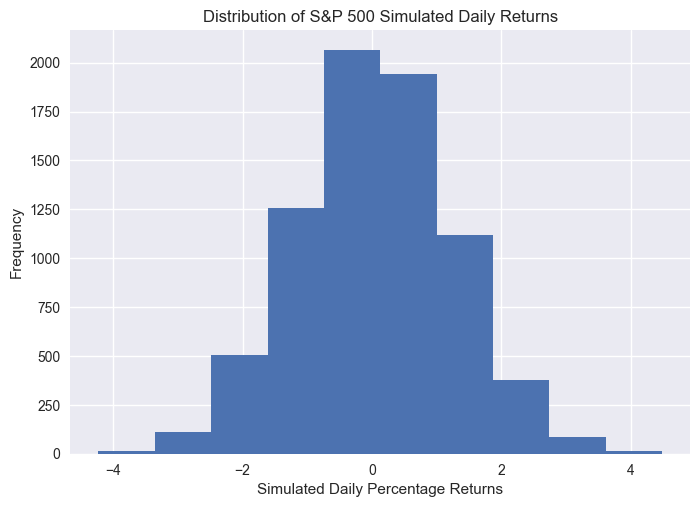

Descriptive statistics of S&P 500 stock's simulated percentage returns:
count    7481.000000
mean        0.050914
std         1.195698
min        -4.227603
25%        -0.748977
50%         0.041095
75%         0.859395
max         4.484413
Name: Simulated, dtype: float64
The skewness of S&P 500 simulated returns is: 0.01 and the kurtosis is: 0.0.


In [5]:
# Estimate the mean and standard deviation from SPY's 30 year historical data
mean = equity['Returns'].mean()
vol = equity['Returns'].std()
sample = equity['Returns'].count()
# Use NumPy's random number generator to sample from a normal distribution
# with the above estimates of its mean and standard deviation
# Create a new column called 'Simulated' and generate the same number of 

# random samples from NumPy's normal distribution as the actual data sample
# you've imported above for SPY
equity['Simulated'] = np.random.normal(mean, vol, sample)
# Visualize and summarize SPY's simulated daily price returns.
plt.hist(equity['Simulated']), plt.title('Distribution of S&P 500 Simulated Daily Returns'), plt.xlabel('Simulated Daily Percentage Returns'), 
plt.ylabel('Frequency'), plt.show()
print("Descriptive statistics of S&P 500 stock's simulated percentage returns:\n{}".
format(equity['Simulated'].describe()))
# Compute the skewness and kurtosis of the simulated daily price returns.
print('The skewness of S&P 500 simulated returns is: {0} and the kurtosis is: {1}.'.format(equity['Simulated'].skew().round(2), equity['Simulated'].kurtosis().round(2)))

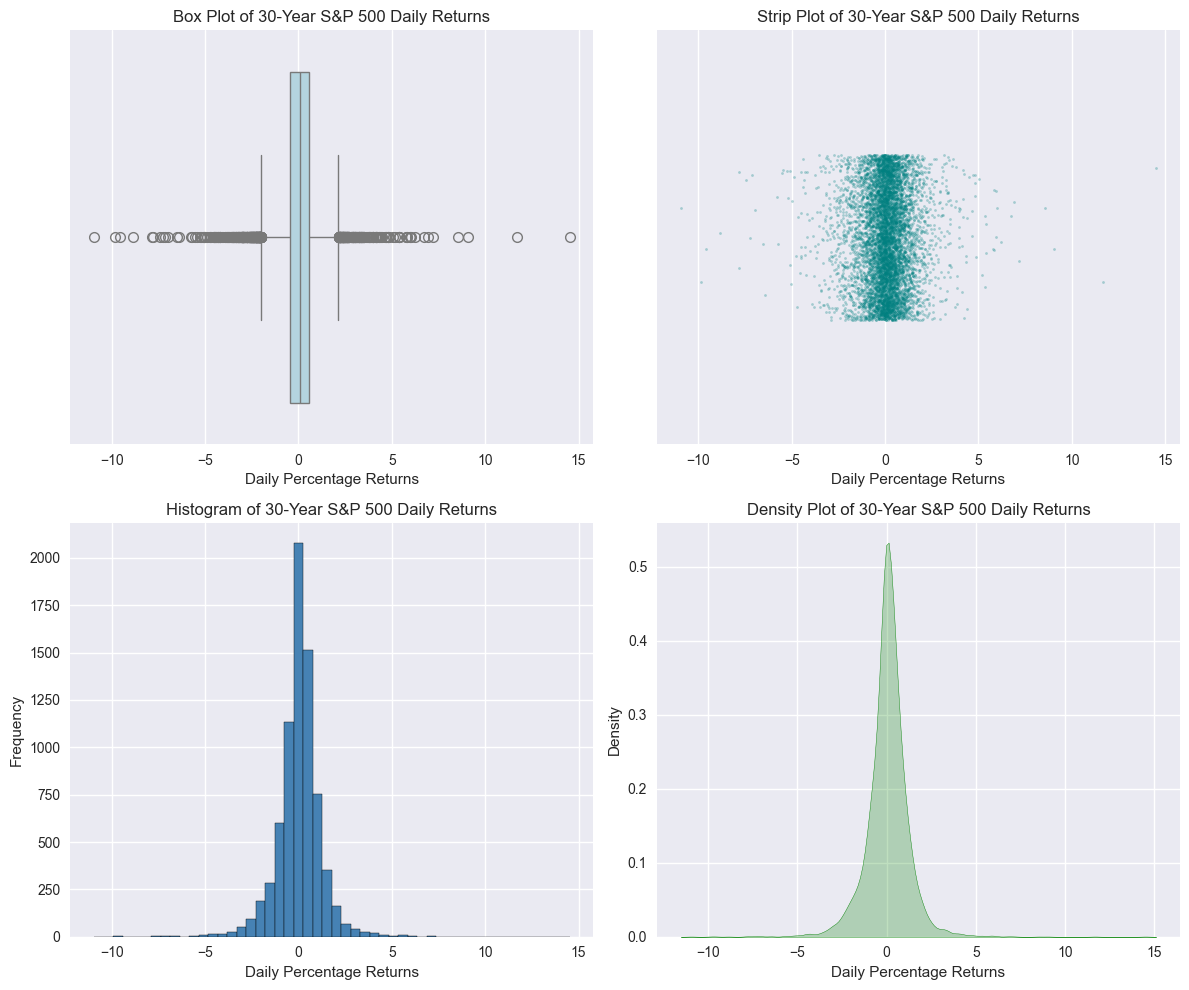

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(x=equity['Returns'], ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Box Plot of 30-Year S&P 500 Daily Returns')
axes[0, 0].set_xlabel('Daily Percentage Returns')

sns.stripplot(x=equity['Returns'], ax=axes[0, 1], color='teal', alpha=0.3, jitter=0.2, size=2)
axes[0, 1].set_title('Strip Plot of 30-Year S&P 500 Daily Returns')
axes[0, 1].set_xlabel('Daily Percentage Returns')

axes[1, 0].hist(equity['Returns'], bins=50, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Histogram of 30-Year S&P 500 Daily Returns')
axes[1, 0].set_xlabel('Daily Percentage Returns')
axes[1, 0].set_ylabel('Frequency')

sns.kdeplot(equity['Returns'], fill=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Density Plot of 30-Year S&P 500 Daily Returns')
axes[1, 1].set_xlabel('Daily Percentage Returns')

plt.tight_layout()
plt.show()